In [4]:
# Step 1 - Import Libraries
# tensorflow is our main deep learning framework
import tensorflow as tf

# matplotlib lets us visualize images and training results
import matplotlib.pyplot as plt

# numpy helps us work with numbers and arrays
import numpy as np

# partial lets us create a "default" version of a function with preset settings
# we'll use this later to avoid repeating ourselves when building the CNN
from functools import partial

In [5]:
# Step 2 - Load the Data

# load training images from the train folder
# image_size resizes all images to 64x64 pixels so they're all the same size
# batch_size=32 means we feed 32 images at a time to the model during training
train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:/Users/KOKO/Desktop/FruitClassifier/dataset/train",
    image_size=(64, 64),
    batch_size=32
)

# load test images — same settings, different folder
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:/Users/KOKO/Desktop/FruitClassifier/dataset/test",
    image_size=(64, 64),
    batch_size=32
)

Found 2301 files belonging to 10 classes.
Found 1025 files belonging to 10 classes.


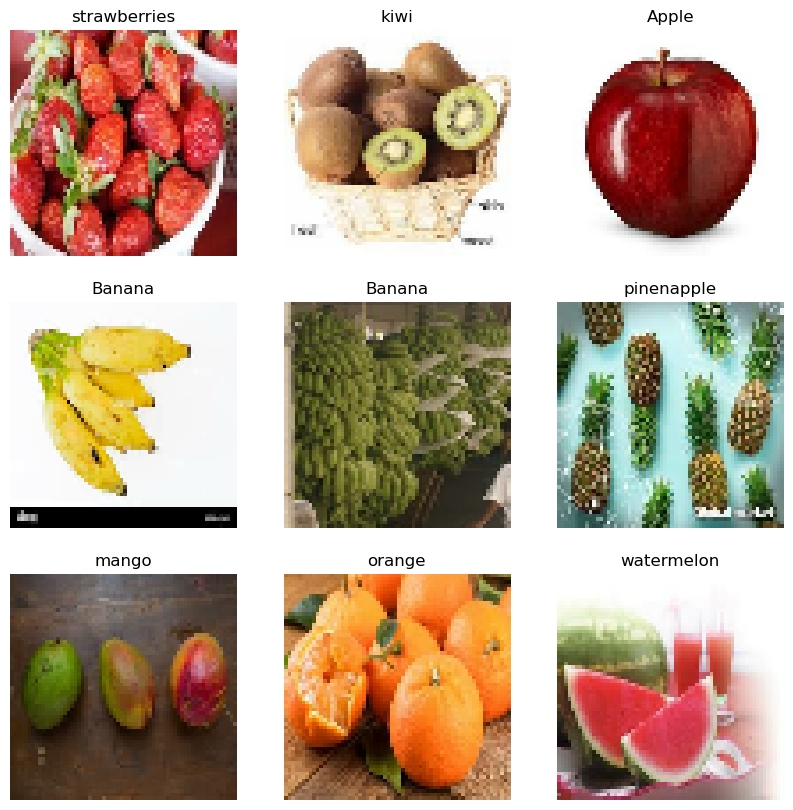

In [6]:
# Step 2.5 - Visualize Some Training Images
# this helps us make sure the data loaded correctly before we do anything else

# create a 10x10 figure to display our images
plt.figure(figsize=(10, 10))

# take(1) grabs just the first batch of 32 images
for images, labels in train_ds.take(1):
    
    # show 9 images in a 3x3 grid
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # imshow expects values 0-255, so we convert back with astype("uint8")
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # class_names gives us the fruit name from the label number e.g. 0 → "Apple"
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [7]:
# Step 3 - Normalize the Data

# pixel values in images range from 0 to 255 (e.g. 128, 200, 45...)
# neural networks work much better when numbers are small (between 0 and 1)
# so we divide every pixel by 255 to shrink the range → 0.0 to 1.0
normalization_layer = tf.keras.layers.Rescaling(1./255)

# apply the normalization to every image in the training set
# lambda x, y means: for each (image, label) pair, rescale the image, keep the label as is
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# same for the test set
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [8]:
# Step 4 - Build the CNN Model

# DefaultConv2D is our shortcut using partial
# we lock in the settings that every Conv2D layer will share:
# - kernel_size=3 → a 3x3 window slides across the image to detect patterns
# - padding="same" → keeps the image the same size after the convolution
# - activation="relu" → turns negative values to 0, keeps positive ones
# - kernel_initializer="he_normal" → smart way to set the starting weights
DefaultConv2D = partial(tf.keras.layers.Conv2D,
                        kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")

model = tf.keras.Sequential([
    # first conv layer uses kernel_size=7 to capture big patterns first
    # input_shape tells the model what to expect: 64x64 images with 3 color channels (RGB)
    DefaultConv2D(filters=32, kernel_size=7, input_shape=[64, 64, 3]),
    
    # MaxPooling shrinks the image by half (64x64 → 32x32)
    # it keeps only the strongest signal from each 2x2 block
    tf.keras.layers.MaxPooling2D(),

    # two conv layers to detect more complex patterns
    DefaultConv2D(filters=64),
    DefaultConv2D(filters=64),
    # shrink again: 32x32 → 16x16
    tf.keras.layers.MaxPooling2D(),

    # two more conv layers to detect even more complex patterns
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    # shrink again: 16x16 → 8x8
    tf.keras.layers.MaxPooling2D(),

    # Flatten converts the 2D feature maps into a 1D vector
    # so we can feed it into regular Dense layers
    tf.keras.layers.Flatten(),

    # Dense layer to combine everything learned by the conv layers
    tf.keras.layers.Dense(256, activation="relu", kernel_initializer="he_normal"),
    
    # Dropout randomly turns off 50% of neurons during training
    # this forces the model to not rely on any single neuron → prevents overfitting
    tf.keras.layers.Dropout(0.5),

    # output layer: 10 neurons, one per fruit class
    # softmax turns the outputs into probabilities that add up to 1
    # e.g. 80% Apple, 15% Kiwi, 5% other...
    tf.keras.layers.Dense(10, activation="softmax")
])

c:\Users\KOKO\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Step 5 - Compile the Model
# this is where we tell the model HOW to learn

# loss function: measures how wrong the model is after each batch
# sparse_categorical_crossentropy is used when we have multiple classes (10 fruits)
# and our labels are integers (0, 1, 2... not one-hot encoded)

# optimizer: the strategy the model uses to fix its mistakes
# sgd = Stochastic Gradient Descent, a classic optimizer
# it nudges the weights in the direction that reduces the loss

# metrics: what we want to monitor during training
# accuracy = how many images the model classified correctly
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [10]:
# Step 6 - Train the Model
# epochs=20 means the model will go through all 2301 training images 20 times
# each epoch it gets a little better at recognizing fruits
# validation_data=test_ds lets us see how it performs on unseen images after each epoch
history = model.fit(train_ds, epochs=20, validation_data=test_ds)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.1643 - loss: 2.2599 - val_accuracy: 0.2380 - val_loss: 2.0228
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.2560 - loss: 1.9741 - val_accuracy: 0.3288 - val_loss: 1.8382
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3116 - loss: 1.8308 - val_accuracy: 0.3551 - val_loss: 1.7762
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3477 - loss: 1.7089 - val_accuracy: 0.3824 - val_loss: 1.7634
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.3946 - loss: 1.6120 - val_accuracy: 0.3756 - val_loss: 1.7664
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.4042 - loss: 1.5885 - val_accuracy: 0.3580 - val_loss: 1.6812
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.4368 - loss: 1.5044 - val_accuracy: 0.4068 - val_loss: 1.6145
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.4502 - loss: 1.4536 - val_accuracy: 0.3863 - v